In [9]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential

In [2]:
if tf.config.list_physical_devices('GPU'):
    print(f"GPU runtime detected")
    print(tf.config.list_physical_devices('GPU'))
else:
    print("No GPU detected.")

GPU runtime detected
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
# load the data
data = np.load("./processed_data/crop_data.npz")
Xtrain = data['Xtrain']
Ytrain = data['Ytrain']
Xtest = data['Xtest']
Ytest = data['Ytest']

In [102]:
model = Sequential()
model.add(Dense(5,activation='relu'))
# model.add(Dropout(0.8))
model.add(Dense(5, activation='tanh'))
# model.add(Dropout(0.7))
model.add(Dense(1, activation='sigmoid'))

In [103]:
model.compile(loss= 'binary_crossentropy', optimizer= tf.keras.optimizers.Adam(0.01) , metrics=[ 'accuracy' ])

In [104]:
# with tf.device("/GPU:0"):
history = model.fit(Xtrain, Ytrain, epochs=50, batch_size=10)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6373 - loss: 0.6459
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8171 - loss: 0.4756 
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8144 - loss: 0.4366 
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8132 - loss: 0.4374 
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7890 - loss: 0.4497 
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8403 - loss: 0.3759 
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8444 - loss: 0.3557 
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8389 - loss: 0.3685 
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8377 - loss: 0.3627 
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8565 - loss: 0.3410 
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8414 - loss: 0.3324 
Epoch 12/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0

In [105]:
with tf.device("/gpu:0"):
    preds = model.predict(Xtest)
    scores = model.evaluate(Xtest, Ytest)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9144 - loss: 0.2459
compile_metrics: 91.09%


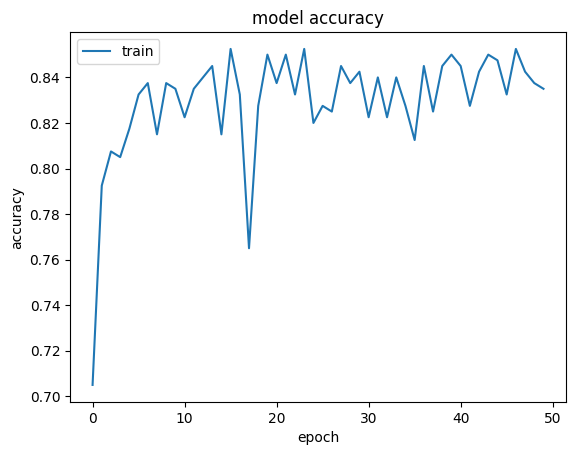

In [106]:
from matplotlib import pyplot as plt
plt.plot(history.history[ "accuracy" ])
plt.title( "model accuracy" )
plt.ylabel( "accuracy" )
plt.xlabel( "epoch" )
plt.legend([ "train" , "test" ], loc= "upper left" )
plt.show()

In [ ]:
model.save("../model/keras_model.keras")